<a href="https://colab.research.google.com/github/harshsu7/Linear-Regression/blob/main/KFolds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cross Validation
- K Fold & Stratified K Fold

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

In [ ]:
data = load_iris()
X, y = data.data, data.target

In [ ]:
model = RandomForestClassifier()

In [ ]:
# K - Fold
kf = KFold(n_splits=5)

scores_kf = cross_val_score(model, X, y, cv=kf)

print("K-Fold Scores:", scores_kf)
print("Mean Accuracy:", scores_kf.mean())

K-Fold Scores: [1.         1.         0.86666667 0.93333333 0.76666667]
Mean Accuracy: 0.9133333333333333


In [ ]:
# Stratified K Fold
skf = StratifiedKFold(n_splits=5,shuffle = True, random_state=42)

scores_skf = cross_val_score(model, X, y, cv=skf)

print("Stratified K-Fold Scores:", scores_skf)
print("Mean Accuracy:", scores_skf.mean())

Stratified K-Fold Scores: [1.         0.96666667 0.9        1.         0.9       ]
Mean Accuracy: 0.9533333333333334


# Hyperparameter Tuning
- GridSearchCV
- RandomizedSearchCV

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

In [ ]:
iris = load_iris()
X, y = iris.data, iris.target

In [ ]:
rf = RandomForestClassifier(random_state=42)

# let's define the Hyperparameter Space
Find the best:
- Number of trees (n_estimators)
- Depth of trees (max_depth)
- Minimum samples to split a node (min_samples_split)

In [ ]:
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# GridSearchCV saare combinations ko check karega (4 * 4 * 3 * 2 = 96 combinations)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X, y)

print(f"GridSearch Best Params: {grid_search.best_params_}")
print(f"GridSearch Best Score: {grid_search.best_score_:.4f}\n")

Fitting 5 folds for each of 96 candidates, totalling 480 fits
GridSearch Best Params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 10}
GridSearch Best Score: 0.9667



In [ ]:
# RandomizedSearchCV will pick 'n_iter' random combinations
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid,
                                   n_iter=10, cv=5, n_jobs=-1, verbose=1, random_state=42)
random_search.fit(X, y)

print(f"RandomSearch Best Params: {random_search.best_params_}")
print(f"RandomSearch Best Score: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
RandomSearch Best Params: {'n_estimators': 10, 'min_samples_split': 10, 'max_depth': 10, 'criterion': 'entropy'}
RandomSearch Best Score: 0.9667


# Bias Variance tradeoff through referenced examples

In [19]:
# 1. Load Data
iris = load_iris()
X, y = iris.data, iris.target

# 2.parameter range (Tree Depth from 1 to 10)
param_range = np.arange(1, 11)

In [20]:
# 3. Calculate Training and Test scores using Cross-Validation
train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(), X, y,
    param_name="max_depth",
    param_range=param_range,
    cv=5, scoring="accuracy"
)

# 4. Calculate Mean and Standard Deviation
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

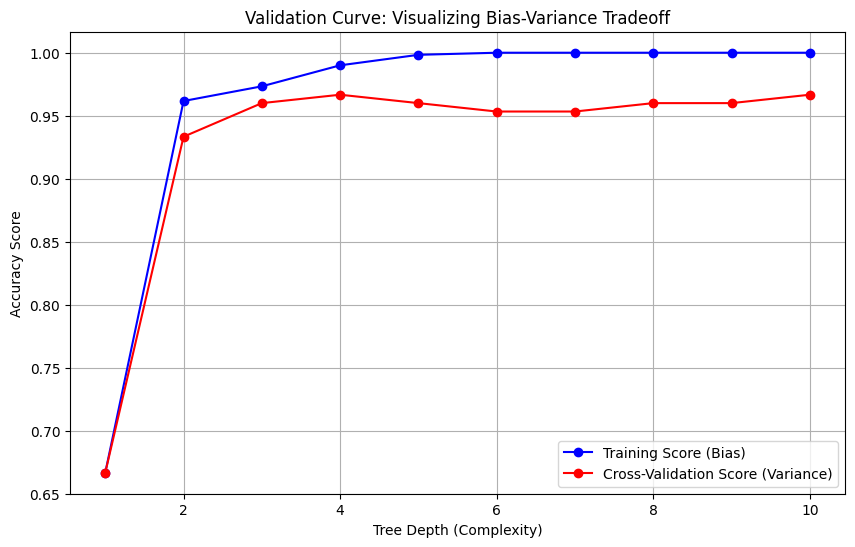

In [21]:
# 5. Plot the Bias-Variance Tradeoff
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Training Score (Bias)", color="blue", marker='o')
plt.plot(param_range, test_mean, label="Cross-Validation Score (Variance)", color="red", marker='o')
plt.title("Validation Curve: Visualizing Bias-Variance Tradeoff")
plt.xlabel("Tree Depth (Complexity)")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid()
plt.show()

# PCA with Eigen Decomposition

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

In [13]:
# 1. Load data with 30 features (High potential for Variance!)
data = load_breast_cancer()
X = StandardScaler().fit_transform(data.data)

# 2. Apply PCA (Keep all components to see the full picture)
pca = PCA()
pca.fit(X)

PCA()

In [14]:
# 3. Cumulative Explained Variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 4. Scree Plot + Cumulative Variance
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

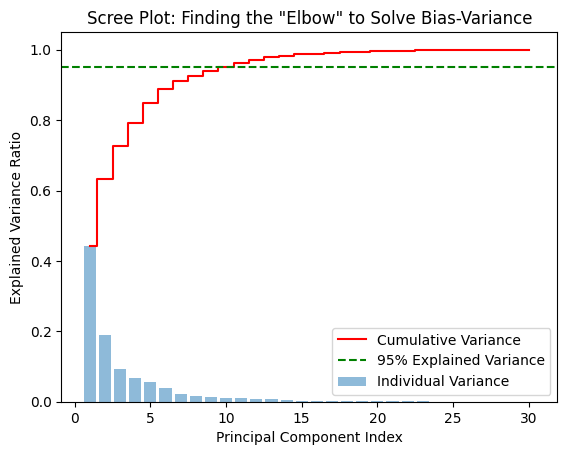

In [16]:
# individual explained variance (Bar)
plt.bar(range(1, 31), pca.explained_variance_ratio_, alpha=0.5, label='Individual Variance')
# cumulative variance (Step/Line)
plt.step(range(1, 31), cumulative_variance, where='mid', label='Cumulative Variance', color='red')

plt.axhline(y=0.95, color='g', linestyle='--', label='95% Explained Variance')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot: Finding the "Elbow" to Solve Bias-Variance')
plt.legend()
plt.show()